In [ ]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Conv1D, MaxPooling1D, UpSampling1D,
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_squared_error

from datetime import datetime

In [ ]:
# DATASET

PATH_TRAINING_A = '../data/preprocessing/normalized/normalized_local_original.npy'
lines_a_noisy = np.load(PATH_TRAINING_A)[:10000]

train_norm, temp = train_test_split(lines_a_noisy, test_size=0.2, random_state=42)  # 20% for val+test
val_norm, test_norm = train_test_split(temp, test_size=0.5, random_state=42)  # split temp equally 10% for val and test each 


#VARIATION IS TOO LITTLE, GRADIENTS ARE VANISHING

In [116]:
#AE ARCHITECTURE

timesteps = 64
features = 2
latent_dim = 32  #Adjust for tighter bottleneck

inputs = Input(shape=(timesteps, features))

encoded = LSTM(128, return_sequences=True)(inputs)
encoded = LSTM(64, return_sequences=True)(encoded)
encoded = LSTM(latent_dim)(encoded)

decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(64, return_sequences=True)(decoded)
decoded = LSTM(128, return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(features))(decoded)

lstm_autoencoder = Model(inputs, decoded)
#autoencoder.summary()


In [ ]:
#TRAINING SETUP 

epochs = 100
batch_size = 32
loss = 'huber' #mse, mae

early_stop = EarlyStopping(
    monitor='val_loss',     # what to watch
    patience=20,            # epochs to wait for improvement, If noisy → increase to 30, If stable → reduce to 10–15
    restore_best_weights=True   # IMPORTANT
)

# metrics: things to be observed, loss: what is actually used for learning
lstm_autoencoder.compile(optimizer='adam', loss=loss, metrics=['mse', 'mae', 'cosine_similarity'])

In [118]:
#TRAINING

timestamp = datetime.now().strftime("%d%m_%H%M")

history = lstm_autoencoder.fit(
    train_norm, train_norm,
    validation_data=(val_norm, val_norm),
    epochs=100,
    batch_size=32,
    shuffle=True,
    callbacks=[early_stop]
)


Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - cosine_similarity: 0.9040 - loss: 0.0121 - mae: 0.0971 - mse: 0.0242 - val_cosine_similarity: 0.9457 - val_loss: 0.0047 - val_mae: 0.0694 - val_mse: 0.0095
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - cosine_similarity: 0.9647 - loss: 0.0031 - mae: 0.0551 - mse: 0.0061 - val_cosine_similarity: 0.9770 - val_loss: 0.0018 - val_mae: 0.0457 - val_mse: 0.0036
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - cosine_similarity: 0.9801 - loss: 0.0014 - mae: 0.0376 - mse: 0.0027 - val_cosine_similarity: 0.9855 - val_loss: 9.2130e-04 - val_mae: 0.0297 - val_mse: 0.0018
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - cosine_similarity: 0.9841 - loss: 9.6587e-04 - mae: 0.0312 - mse: 0.0019 - val_cosine_similarity: 0.9837 - val_loss: 9.1879e-04 - val_mae: 0.0316 - val_mse: 0.0018
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - cosine_similarity: 0.9854 - loss: 8.8312e-04 - mae: 0.0301 - mse: 0.0018 - val_

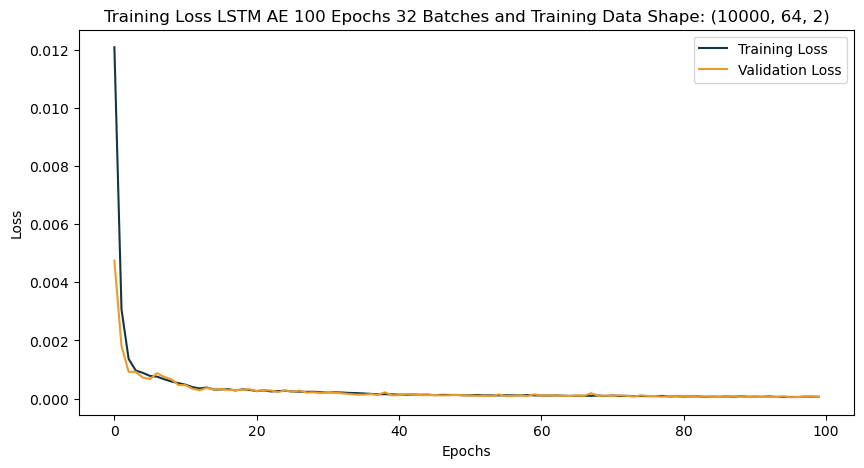

In [119]:
# TRAINING HISTORY 
#MAE between two lines is on the order of 10⁻⁵ to 10⁻⁶, gradients are vanishing and the model cannot update meaningfully 

def plot_history(history, epochs, batch_size, train_data_noisy):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss', color='#143642')

    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='#EC9A29')

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Training Loss LSTM AE {epochs} Epochs {batch_size} Batches and Training Data Shape: {train_data_noisy.shape}')
    plt.show()


plot_history(history, epochs, batch_size, lines_a_noisy)

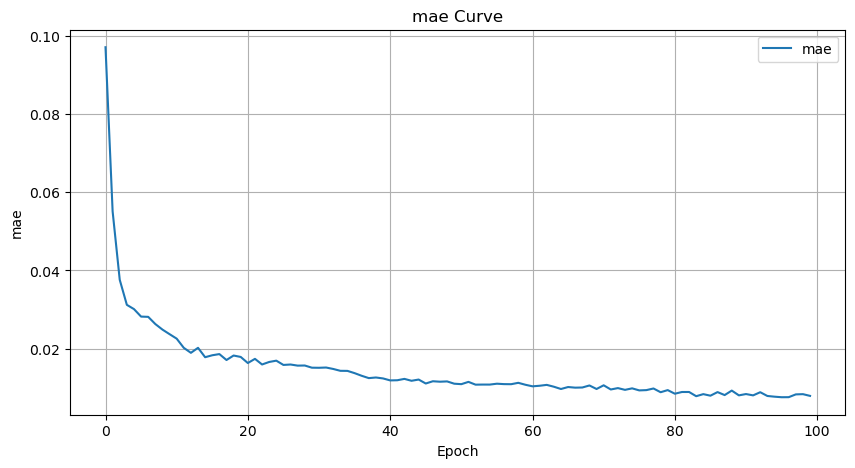

In [120]:
loss = 'mae' #'mae', 'cosine_similarity'

plt.figure(figsize=(10,5))
plt.plot(history.history[f'{loss}'], label=f'{loss}')
plt.xlabel('Epoch')
plt.ylabel(f'{loss}')
plt.title(f'{loss} Curve')
plt.legend()
plt.grid(True)
plt.show()


In [122]:
lstm_autoencoder.save(f'../checkpoints/autoencoder/model/{batch_size}_batches_{epochs}_epochs_huber_local_{timestamp}.keras')

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


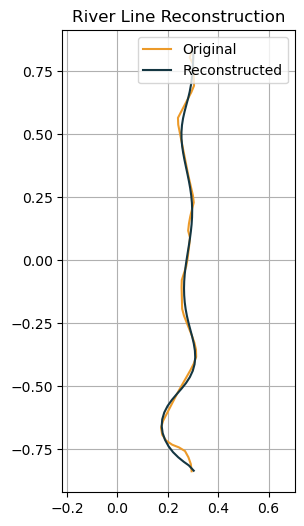

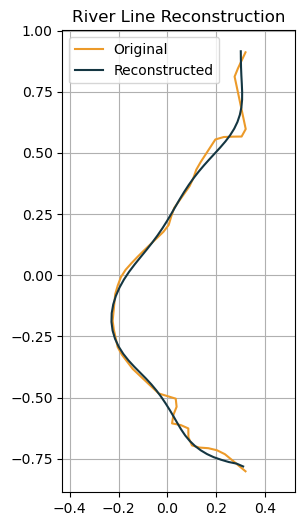

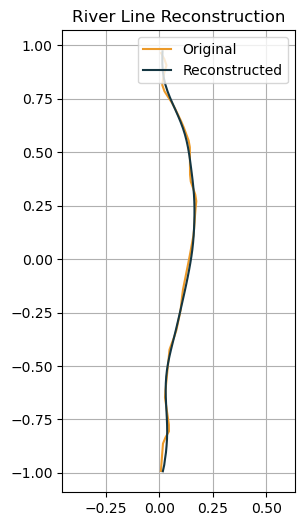

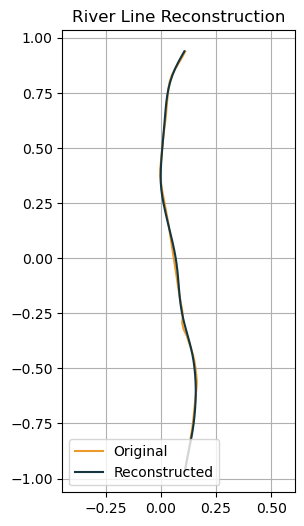

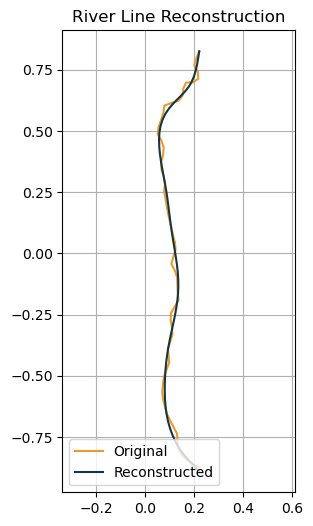

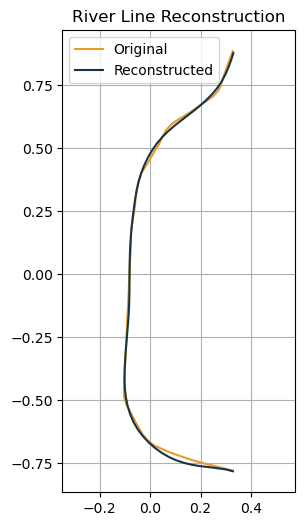

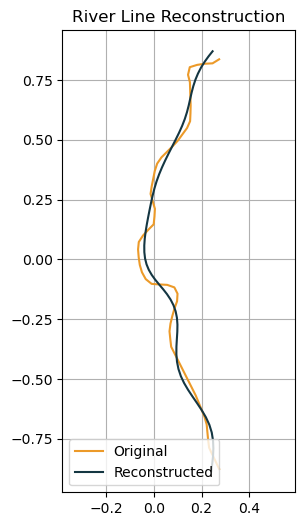

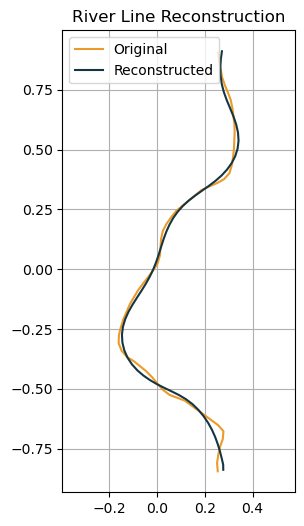

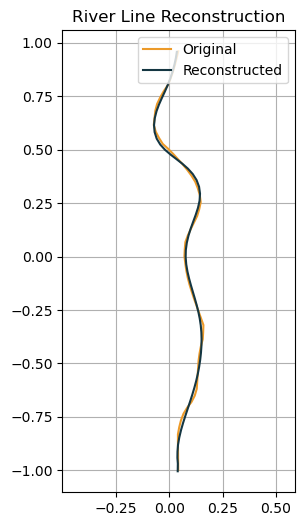

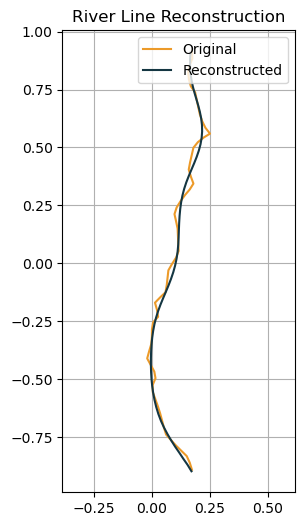

In [125]:
# PREDICTION

reconstructed = lstm_autoencoder.predict(test_norm)

for i in range(110,120):
    plt.figure(figsize=(3,6))
    #plt.figsize=(10, 6)
    plt.plot(test_norm[i,:,0], test_norm[i,:,1], color='#EC9A29', label='Original')
    plt.plot(reconstructed[i,:,0], reconstructed[i,:,1], color='#143642', label='Reconstructed')
    plt.legend()
    plt.axis('equal')
    plt.grid(True)
    plt.title('River Line Reconstruction')
    plt.show()


## CONVOLUTIONAL NOT LSTM

You can adjust the level of simplification by changing:

- Depth of encoder (fewer pooling layers → more detail retained)

- Number of filters (fewer filters → smoother)

- Latent bottleneck size (smaller → more compression → less detail)


In [76]:
# Assume train_data: (700, 64, 2), test_data: (150, 64, 2)

# === Model definition ===
inputs = Input(shape=(64, 2))

# Encoder
x = Conv1D(64, 3, activation='relu', padding='same')(inputs)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(32, 3, activation='relu', padding='same')(x)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(16, 3, activation='relu', padding='same')(x)
encoded = MaxPooling1D(2, padding='same')(x)  # now 4x shorter

# Decoder (must invert: 4x, then 2x, then 2x)
x = Conv1D(16, 3, activation='relu', padding='same')(encoded)
x = UpSampling1D(2)(x)
x = Conv1D(32, 3, activation='relu', padding='same')(x)
x = UpSampling1D(2)(x)
x = Conv1D(64, 3, activation='relu', padding='same')(x)
x = UpSampling1D(2)(x)
decoded = Conv1D(2, 3, activation='sigmoid', padding='same')(x)

conv_autoencoder = Model(inputs, decoded)
conv_autoencoder.compile(optimizer='adam', loss='mae')

#conv_autoencoder.summary()


In [ ]:
history = conv_autoencoder.fit(
    train_norm, train_norm,
    epochs=10,
    batch_size=32, #16
    shuffle=True
)

In [ ]:
reconstructed = conv_autoencoder.predict(test_norm)

for i in range(100):
    plt.figure(figsize=(3,6))
    plt.plot(test_norm[i,:,0], test_norm[i,:,1], color='#143642', label='Original')
    plt.plot(reconstructed[i,:,0], reconstructed[i,:,1], color='#EC9A29', label='Reconstructed')
    plt.legend()
    plt.title('Vectorline Reconstruction (Conv1D Autoencoder)')
    plt.show()
